[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gduscher/MLSTEM2026/blob/main/Day%202/4PM_Hackathon_Digital_Twin.ipynb)

# Hackathon Digital Twin

This notebook is a guided workshop built around a simulated scanning diffraction experiment. The opening sections are worked examples: connect to the instrument, acquire HAADF and diffraction data, segment the particles, and recover one local lattice parameter. The open-ended hackathon exercises begin after those examples.

The twin contains round and oval FCC nanoparticles viewed along the `<100>` zone-axis family.

## Google Colab setup

In Colab, run the following cell


In [ ]:
import os
import subprocess
import sys
from pathlib import Path

subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'uv'], check=True)

COLAB_REPO_DIR = Path('/content/asyncroscopy')
if not (COLAB_REPO_DIR / '.git').exists():
    subprocess.run(['git', 'clone', '--branch', 'dev-ACH', '--single-branch', 'https://github.com/pycroscopy/asyncroscopy.git', str(COLAB_REPO_DIR)], check=True)

os.chdir(COLAB_REPO_DIR)
subprocess.run(['uv', 'sync', '--extra', 'diffraction'], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'ipympl>=0.9', 'pytango==10.1.2', 'tiled[all]>=0.2.9'], check=True)
print('Installation complete. Restart the Colab session before continuing.')

### Restart the Colab session

Select **Runtime > Restart session**, then continue with the next cell. The installed packages and `.venv` remain available after the restart.

In [ ]:
import os
import socket
import subprocess
import time
from pathlib import Path

import ipympl
from google.colab import output

output.enable_custom_widget_manager()
COLAB_REPO_DIR = Path('/content/asyncroscopy')
venv_python = COLAB_REPO_DIR / '.venv/bin/python'
print(f'ipympl {ipympl.__version__}')

os.environ['TANGO_HOST'] = '127.0.0.1:9094'
server_log_path = COLAB_REPO_DIR / 'servers.log'
startup_script = COLAB_REPO_DIR / 'startup_scripts/run_servers.py'
config_path = COLAB_REPO_DIR / 'configs/diffraction.yaml'

try:
    with socket.create_connection(('127.0.0.1', 9094), timeout=0.25):
        server_running = True
except OSError:
    server_running = False

if server_running:
    print('A Tango server is already listening on 127.0.0.1:9094.')
else:
    server_log = server_log_path.open('w')
    colab_server_process = subprocess.Popen(
        [
            str(venv_python), '-u', str(startup_script),
            '--yaml', str(config_path),
        ],
        cwd=COLAB_REPO_DIR,
        stdout=server_log,
        stderr=subprocess.STDOUT,
        env={**os.environ, 'PYTHONUNBUFFERED': '1'},
    )

    for _ in range(180):
        log_text = server_log_path.read_text(errors='replace') if server_log_path.exists() else ''
        if 'All asyncroscopy servers are ready.' in log_text:
            print('All asyncroscopy servers are ready.')
            break
        if colab_server_process.poll() is not None:
            raise RuntimeError(f'Server startup failed.\n{log_text[-4000:]}')
        time.sleep(1)
    else:
        raise TimeoutError(f'Server startup timed out. Inspect {server_log_path}.')

print('TANGO_HOST=127.0.0.1:9094 | Tiled=http://127.0.0.1:9091')


## Connect to the digital twin

### Imports

In [1]:
%matplotlib widget

import json
import numpy as np
import pandas as pd

from scipy.fft import dctn, idctn
from scipy import ndimage
from scipy import constants

from matplotlib import colors
import matplotlib.pyplot as plt

import tango
from tiled.client import from_uri

### Connect to the Tango device servers

Tango exposes the scan controls, simulated microscope, and data service through the same interfaces used by the rest of asyncroscopy.

In [2]:
DB_HOST = "localhost"
DB_PORT = 9094

os.environ["TANGO_HOST"] = f"{DB_HOST}:{DB_PORT}"

server_names = ['stage', 'scan', 'camera', 'data', 'instrument']

scan = tango.DeviceProxy("asyncroscopy/scan/default")
microscope = tango.DeviceProxy("asyncroscopy/instrument/default")
data = tango.DeviceProxy("asyncroscopy/data/default")

for proxy in [scan, microscope, data]:
    proxy.set_timeout_millis(120_000)
    proxy.ping()
    print(proxy.name(), proxy.state())

asyncroscopy/scan/default ON
asyncroscopy/instrument/default ON
asyncroscopy/data/default ON


### Connect to Tiled

Acquisition commands return a key. Tiled uses that key to retrieve the saved array and its metadata.

In [3]:
config = json.loads(data.get_config())
config

{'host': '127.0.0.1',
 'port': 9091,
 'uri': 'http://127.0.0.1:9091',
 'save_path': 'outputs/tiled_acquisitions',
 'tiled_server': 'yes',
 'tiled_server_status': 'running; serving path; files register manually',
 'tiled_server_serving': 'outputs/tiled_acquisitions'}

In [4]:
client = from_uri(config.get("uri"))
len(client)

52

### Acquire a HAADF overview

In [5]:
key = microscope.acquire_scanned_image(['HAADF'])
key

'stem_image_HAADF_20260622T185149240918.h5'

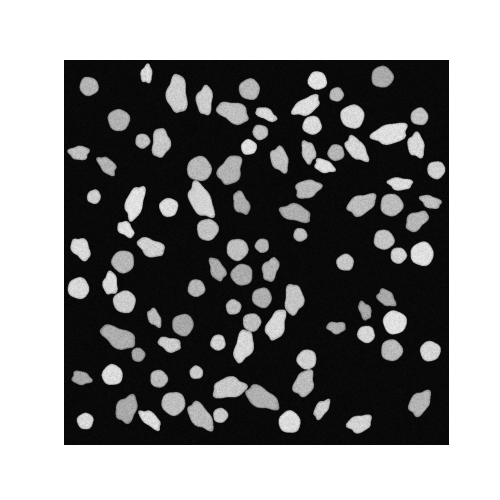

In [6]:
haadf_image = client[key]['image']['HAADF'].read()
metadata = dict(client[key]['image'].metadata)

plt.figure(figsize=(5, 5))
plt.imshow(haadf_image, cmap='gray')
plt.axis('off');

### Park the probe on a particle

Beam positions are fractional `(x, y)` coordinates in `[0, 1]`. The red marker shows where the next local diffraction measurement will be taken.

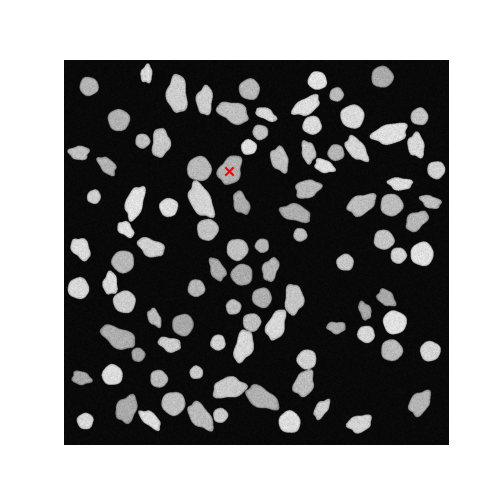

In [7]:
position = [440/1024,296/1024]
microscope.place_beam(position)

plt.figure(figsize=(5, 5))
plt.imshow(haadf_image, cmap='gray')
plt.scatter(position[0]*haadf_image.shape[1], position[1]*haadf_image.shape[0], color='red', marker='x')
plt.axis('off');

### Acquire a diffraction pattern

In [8]:
key = microscope.acquire_camera_image()
key

'diffraction_BM-Ceta_20260622T185158090754.h5'

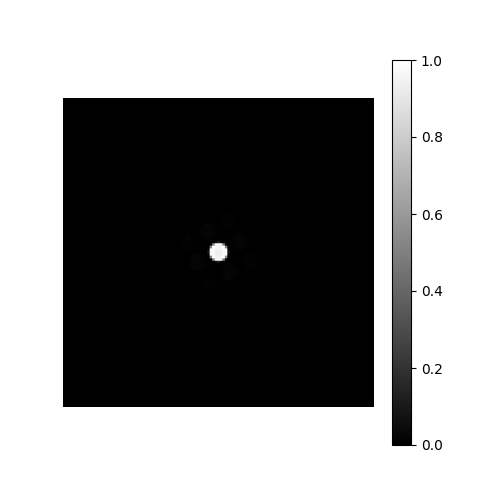

In [9]:
image = client[key]['image'].read()
metadata = dict(client[key]['image'].metadata)

plt.figure(figsize=(5, 5))
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.colorbar()

## Worked example: characterize particles from HAADF

Diffraction is the expensive measurement, so this overview is the information used to decide where to spend the acquisition budget.

1. segments all particles 
2. measures rotation-invariant size and shape statistics;
3. maps each statistic back onto the overview;
4. provides features that can guide later sampling decisions.

### Acquire a `1024 × 1024` overview

The twin has a fixed `500 nm` field of view

In [10]:
scan.imsize = 1024
scan.dwell_time = 1e-6

overview_key = microscope.acquire_scanned_image(['HAADF'])
overview_node = client[overview_key]['image']['HAADF']
overview = np.asarray(overview_node.read(), dtype=np.float32)
overview_metadata = dict(overview_node.metadata)

fov_nm = float(overview_metadata.get('fov_nm', 500.0))
pixel_size_nm = float(overview_metadata.get('pixel_size_nm', fov_nm / overview.shape[0]))

print(f'key: {overview_key}')
print(f'image shape: {overview.shape}')
print(f'pixel size: {pixel_size_nm:.3f} nm / pixel')

key: stem_image_HAADF_20260622T185205134667.h5
image shape: (1024, 1024)
pixel size: 0.488 nm / pixel


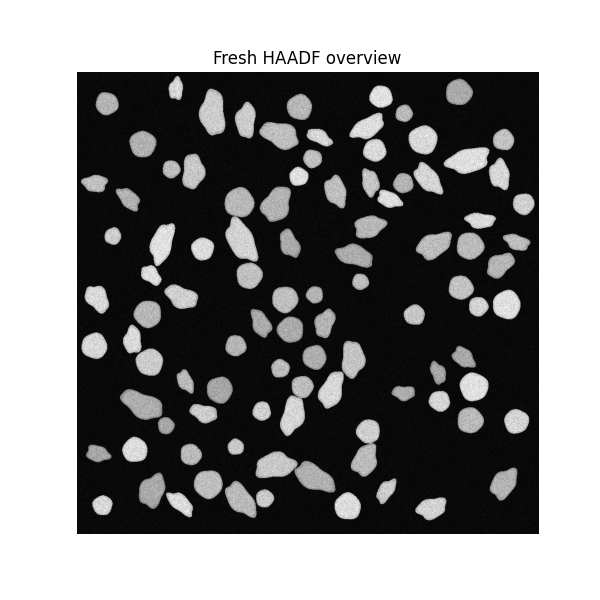

In [11]:
overview_norm = overview - np.nanmin(overview)
if np.nanmax(overview_norm) > 0:
    overview_norm = overview_norm / np.nanmax(overview_norm)

plt.figure(figsize=(6, 6))
plt.imshow(overview_norm, cmap='gray')
plt.title('Fresh HAADF overview')
plt.axis('off');

### Step 1: segment the overview

The example uses Otsu thresholding implemented with NumPy, followed by light cleanup with `scipy.ndimage`

As you inspect the result, ask: does the threshold preserve the full particle boundary? Would the same cleanup work if two particles touched?

In [12]:
smoothed = ndimage.gaussian_filter(overview_norm, sigma=0.8)
hist, bin_edges = np.histogram(smoothed.ravel(), bins=256, range=(0.0, 1.0))
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
weight_bg = np.cumsum(hist)
weight_fg = hist.sum() - weight_bg
sum_bg = np.cumsum(hist * bin_centers)
sum_fg = np.sum(hist * bin_centers) - sum_bg
valid = (weight_bg > 0) & (weight_fg > 0)
between_class_variance = np.zeros_like(bin_centers)
between_class_variance[valid] = weight_bg[valid] * weight_fg[valid] * (sum_bg[valid] / weight_bg[valid] - sum_fg[valid] / weight_fg[valid]) ** 2
otsu_value = float(bin_centers[int(np.argmax(between_class_variance))])

foreground = smoothed >= otsu_value
foreground = ndimage.binary_opening(foreground, structure=np.ones((2, 2), dtype=bool))
labels, label_count = ndimage.label(foreground, structure=np.ones((3, 3), dtype=bool))

print(f'Otsu threshold: {otsu_value:.3f}')
print(f'raw connected components: {label_count}')

Otsu threshold: 0.385
raw connected components: 96


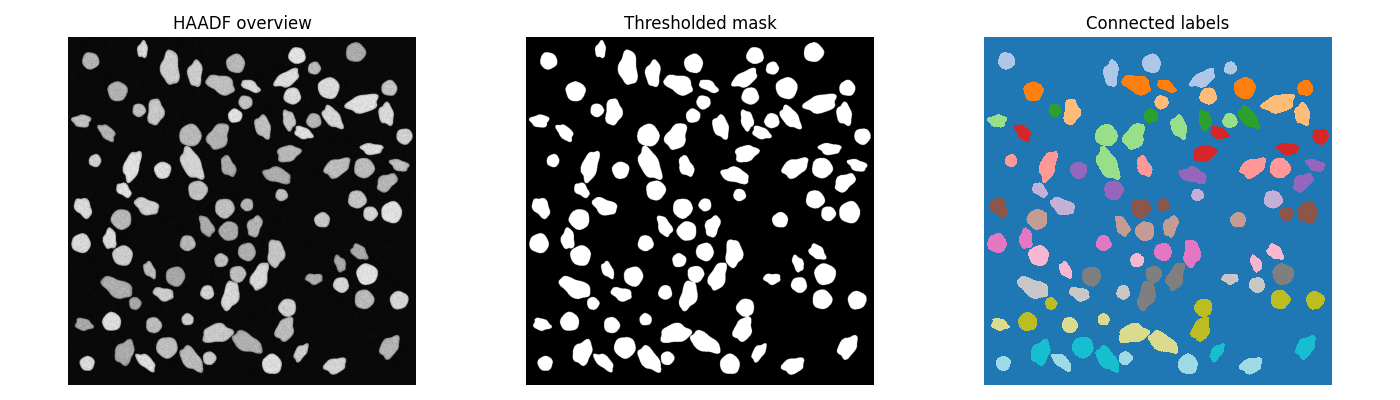

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(overview_norm, cmap='gray')
axes[0].set_title('HAADF overview')
axes[0].axis('off')

axes[1].imshow(foreground, cmap='gray')
axes[1].set_title('Thresholded mask')
axes[1].axis('off')

axes[2].imshow(labels, cmap='tab20', interpolation='nearest')
axes[2].set_title('Connected labels')
axes[2].axis('off')
plt.tight_layout()

### Step 2: compute rotation-invariant particle statistics

Each connected label receives size, center, and shape measurements. Rotation-invariant descriptors are useful because oval particles can point in any in-plane direction.

The table includes:

- area in pixels and `nm²`;
- equivalent radius and center of mass;
- `rmin` and `rmax`, measured from the center to the boundary;
- `rmax / rmin`, a simple orientation-independent irregularity score;
- covariance aspect ratio;
- circularity and radial coefficient of variation.

In [14]:
min_area_px = max(12, int(0.00002 * overview.size))
centroids_yx = ndimage.center_of_mass(np.ones_like(labels, dtype=np.float32), labels, range(1, label_count + 1))
particle_rows = []
filtered_labels = np.zeros_like(labels, dtype=np.int32)
next_label = 1

for label_id, centroid_yx in zip(range(1, label_count + 1), centroids_yx):
    mask = labels == label_id
    area_px = int(np.count_nonzero(mask))
    if area_px < min_area_px or not np.all(np.isfinite(centroid_yx)):
        continue

    cy, cx = centroid_yx
    boundary = mask & ~ndimage.binary_erosion(mask, structure=np.ones((3, 3), dtype=bool), border_value=0)
    boundary_yx = np.column_stack(np.nonzero(boundary)).astype(np.float32)
    if len(boundary_yx) == 0:
        continue

    boundary_xy = boundary_yx[:, ::-1]
    boundary_dist_px = np.sqrt((boundary_xy[:, 0] - cx) ** 2 + (boundary_xy[:, 1] - cy) ** 2)
    rmin_px = float(np.min(boundary_dist_px))
    rmax_px = float(np.max(boundary_dist_px))

    yx = np.column_stack(np.nonzero(mask)).astype(np.float32)
    xy = yx[:, ::-1]
    centered = xy - np.array([[cx, cy]], dtype=np.float32)
    cov = np.cov(centered, rowvar=False) if len(centered) > 2 else np.eye(2)
    eigvals = np.sort(np.linalg.eigvalsh(cov))
    aspect_ratio = float(np.sqrt(eigvals[-1] / max(eigvals[0], 1e-9)))

    padded = np.pad(mask.astype(np.int8), 1)
    perimeter_px = float(np.sum(np.abs(np.diff(padded, axis=0))) + np.sum(np.abs(np.diff(padded, axis=1))))
    circularity = float(4 * np.pi * area_px / max(perimeter_px ** 2, 1e-9))
    radial_cv = float(np.std(boundary_dist_px) / max(np.mean(boundary_dist_px), 1e-9))

    filtered_labels[mask] = next_label
    particle_rows.append({
        'label': next_label,
        'area_px': area_px,
        'area_nm2': area_px * pixel_size_nm ** 2,
        'com_x_px': float(cx),
        'com_y_px': float(cy),
        'equivalent_radius_nm': float(np.sqrt(area_px / np.pi) * pixel_size_nm),
        'rmin_nm': rmin_px * pixel_size_nm,
        'rmax_nm': rmax_px * pixel_size_nm,
        'rmax_over_rmin': rmax_px / max(rmin_px, 1e-9),
        'radial_cv': radial_cv,
        'aspect_ratio_cov': aspect_ratio,
        'circularity': circularity,
    })
    next_label += 1

particle_stats = pd.DataFrame(particle_rows).sort_values('area_px', ascending=False).reset_index(drop=True)
particle_stats.head(12)

,label,area_px,area_nm2,com_x_px,com_y_px,equivalent_radius_nm,rmin_nm,rmax_nm,rmax_over_rmin,radial_cv,aspect_ratio_cov,circularity
0,28,7936,1892.089844,362.106477,336.839718,24.541208,2.347608,43.585413,18.565884,0.475073,2.853347,0.271560
1,70,5315,1267.194748,485.182126,738.063970,20.083840,7.502473,34.746921,4.631395,0.412632,3.052778,0.307568
2,80,5241,1249.551773,641.103797,832.849456,19.943537,2.811363,31.088077,11.058009,0.444407,2.666754,0.308560
3,4,4453,1061.677933,300.729845,90.355042,18.383215,10.894209,26.258689,2.410335,0.224313,1.856542,0.526535
4,16,4129,984.430313,867.025672,195.331315,17.701805,12.042039,26.889157,2.232941,0.228455,1.866836,0.494271
5,73,4105,978.708267,144.100609,736.991717,17.650284,10.525335,25.251053,2.399074,0.234339,1.889128,0.485387
6,85,3983,949.621201,438.899824,871.981672,17.386024,11.727801,24.151951,2.059376,0.188437,1.647232,0.534536
7,86,3922,935.077667,526.234319,898.714941,17.252376,10.542228,25.855913,2.452604,0.232361,1.882260,0.469491
8,27,3774,899.791718,441.991521,292.604663,16.923729,11.946796,21.821037,1.826518,0.145734,1.405653,0.541288
9,10,3736,890.731812,449.688169,139.051124,16.838312,11.271385,22.742229,2.017696,0.190421,1.632123,0.528669


Text(0.5, 0.98, '96 particles: spatial statistics and size trends')

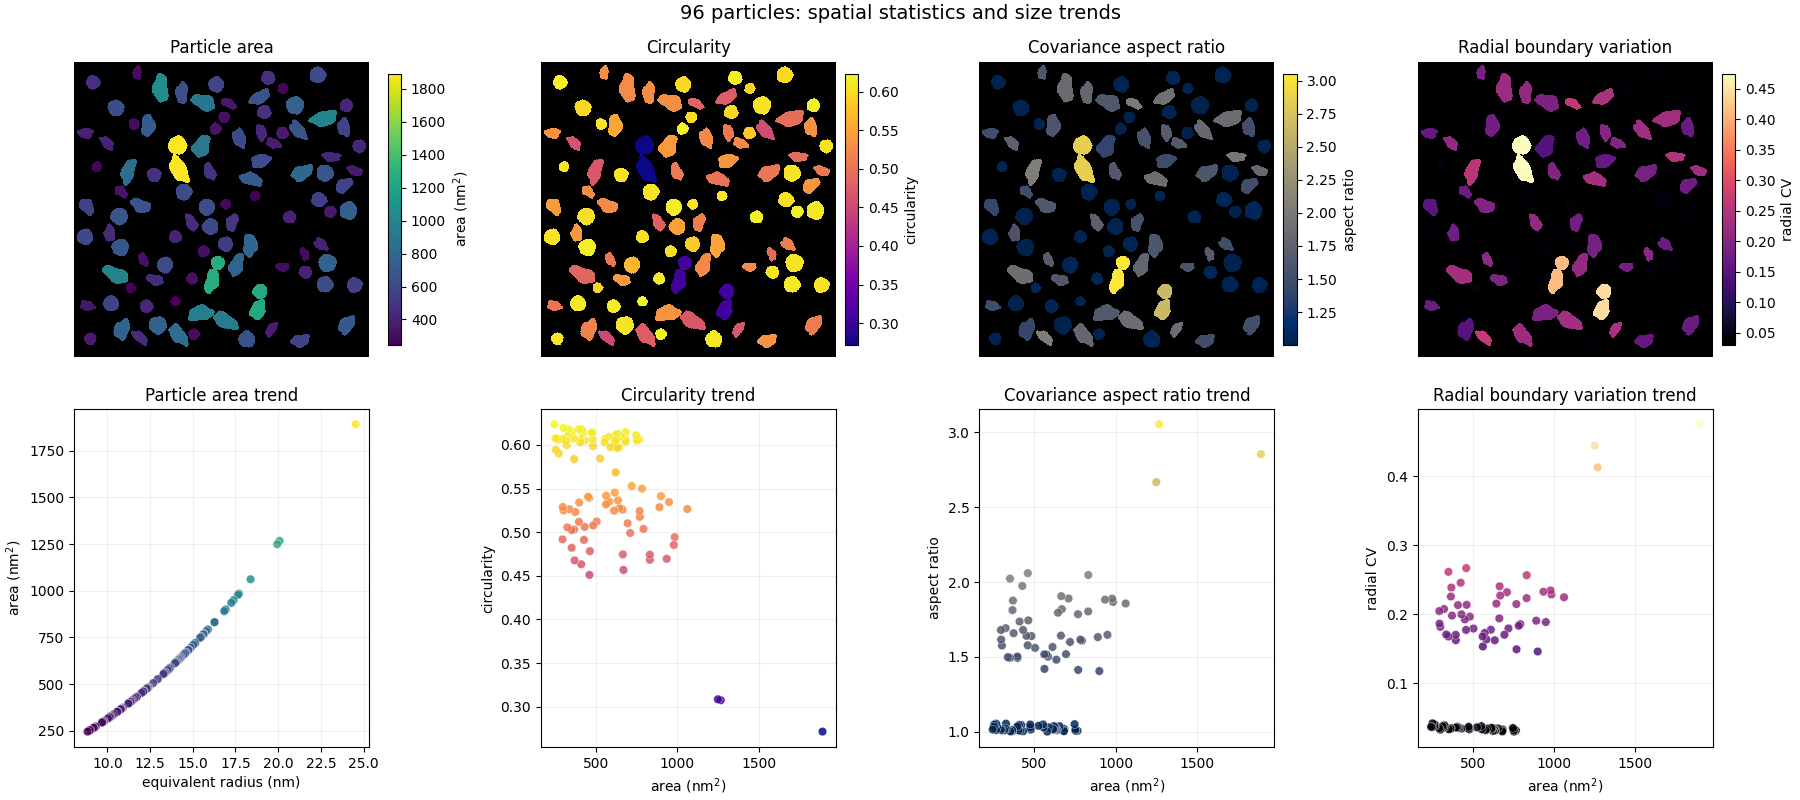

In [15]:
stat_panels = [
    {
        'key': 'area_nm2',
        'title': 'Particle area',
        'ylabel': 'area (nm$^2$)',
        'xkey': 'equivalent_radius_nm',
        'xlabel': 'equivalent radius (nm)',
        'cmap': 'viridis',
    },
    {
        'key': 'circularity',
        'title': 'Circularity',
        'ylabel': 'circularity',
        'xkey': 'area_nm2',
        'xlabel': 'area (nm$^2$)',
        'cmap': 'plasma',
    },
    {
        'key': 'aspect_ratio_cov',
        'title': 'Covariance aspect ratio',
        'ylabel': 'aspect ratio',
        'xkey': 'area_nm2',
        'xlabel': 'area (nm$^2$)',
        'cmap': 'cividis',
    },
    {
        'key': 'radial_cv',
        'title': 'Radial boundary variation',
        'ylabel': 'radial CV',
        'xkey': 'area_nm2',
        'xlabel': 'area (nm$^2$)',
        'cmap': 'magma',
    },
]

fig, axes = plt.subplots(2, len(stat_panels), figsize=(18, 8), constrained_layout=True)
particle_labels = particle_stats['label'].to_numpy(dtype=int)

for column, panel in enumerate(stat_panels):
    values = particle_stats[panel['key']].to_numpy(dtype=float)
    value_by_label = np.full(int(filtered_labels.max()) + 1, np.nan, dtype=float)
    value_by_label[particle_labels] = values
    statistic_image = np.ma.masked_where(filtered_labels == 0, value_by_label[filtered_labels])

    vmin, vmax = float(np.nanmin(values)), float(np.nanmax(values))
    if np.isclose(vmin, vmax):
        vmin, vmax = vmin - 0.5, vmax + 0.5
    norm = colors.Normalize(vmin=vmin, vmax=vmax)
    cmap = plt.colormaps[panel['cmap']].copy()
    cmap.set_bad('black')

    image_ax = axes[0, column]
    image = image_ax.imshow(statistic_image, cmap=cmap, norm=norm, interpolation='nearest')
    image_ax.set_title(panel['title'])
    image_ax.axis('off')
    fig.colorbar(image, ax=image_ax, fraction=0.046, pad=0.03, label=panel['ylabel'])

    scatter_ax = axes[1, column]
    scatter_ax.scatter(
        particle_stats[panel['xkey']],
        values,
        c=values,
        cmap=cmap,
        norm=norm,
        s=38,
        alpha=0.85,
        edgecolors='white',
        linewidths=0.3,
    )
    scatter_ax.set_xlabel(panel['xlabel'])
    scatter_ax.set_ylabel(panel['ylabel'])
    scatter_ax.set_title(f"{panel['title']} trend")
    scatter_ax.grid(alpha=0.2)

fig.suptitle(f'{len(particle_stats)} particles: spatial statistics and size trends', fontsize=14)


## Worked example: recover one local lattice parameter

The digital twin has two deliberately different lattice profiles.

All particles are FCC and viewed along the `<100>` zone-axis family. The first allowed reflection is therefore `{200}`. The following sections show each processing step and its diagnostic plot.

### 1. Acquire a diffraction pattern

Park the beam near the center of the largest segmented particle, acquire one diffraction pattern, and read its angular calibration from metadata.

In [ ]:
target_particle = particle_stats.iloc[0]
beam_position = [
    float(target_particle['com_x_px'] / overview.shape[1]),
    float(target_particle['com_y_px'] / overview.shape[0]),
]
microscope.place_beam(beam_position)

diffraction_key = microscope.acquire_camera_image()
diffraction_node = client[diffraction_key]['image']
diffraction_pattern = np.asarray(diffraction_node.read(), dtype=np.float64)
diffraction_metadata = dict(diffraction_node.metadata)
pixel_size_mrad = float(diffraction_metadata['pixel_size_mrad'])

print(f'diffraction key: {diffraction_key}')
print(f'angular pixel size: {pixel_size_mrad:.4f} mrad / pixel')

fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
axes[0].imshow(overview, cmap='gray')
axes[0].scatter(target_particle['com_x_px'], target_particle['com_y_px'], s=70, facecolors='none', edgecolors='tab:red', linewidths=2)
axes[0].set_title('Selected particle and beam position')
axes[0].axis('off')
axes[1].imshow(np.log1p(1000 * diffraction_pattern), cmap='magma')
axes[1].set_title('Acquired diffraction pattern')
axes[1].axis('off')

### 2. Isolate and center the zero beam

Threshold the central disk, retain its connected component, and refine the diffraction center using its intensity-weighted centroid.

In [ ]:
from scipy import ndimage

yy, xx = np.indices(diffraction_pattern.shape, dtype=float)
image_cy = (diffraction_pattern.shape[0] - 1) / 2
image_cx = (diffraction_pattern.shape[1] - 1) / 2
radius_from_image_center = np.hypot(xx - image_cx, yy - image_cy)
central_roi = radius_from_image_center < 0.08 * min(diffraction_pattern.shape)
zero_beam_threshold = 0.5 * float(diffraction_pattern[central_roi].max())
zero_beam_candidates = central_roi & (diffraction_pattern >= zero_beam_threshold)

candidate_labels, _ = ndimage.label(zero_beam_candidates)
center_label = candidate_labels[int(round(image_cy)), int(round(image_cx))]
zero_beam_mask = ndimage.binary_fill_holes(candidate_labels == center_label)
zero_beam_weights = np.where(zero_beam_mask, diffraction_pattern, 0.0)
beam_cy = float(np.sum(yy * zero_beam_weights) / np.sum(zero_beam_weights))
beam_cx = float(np.sum(xx * zero_beam_weights) / np.sum(zero_beam_weights))
radius_px = np.hypot(xx - beam_cx, yy - beam_cy)
zero_beam_radius_px = float(np.percentile(radius_px[zero_beam_mask], 99))

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
axes[0].imshow(np.log1p(1000 * diffraction_pattern), cmap='magma')
axes[0].contour(zero_beam_mask, levels=[0.5], colors='cyan', linewidths=1.5)
axes[0].scatter(beam_cx, beam_cy, marker='+', s=100, color='white')
axes[0].set_title('Detected zero-beam boundary and center')
axes[0].axis('off')
axes[1].imshow(zero_beam_weights, cmap='gray')
axes[1].set_title(f'Extracted zero beam ({zero_beam_radius_px * pixel_size_mrad:.2f} mrad radius)')
axes[1].axis('off')

### 3. Deconvolve the diffraction pattern

Use the measured zero beam as the point-spread function for Richardson–Lucy deconvolution, then suppress the residual direct beam.

In [ ]:
from scipy import signal

beam_y, beam_x = np.nonzero(zero_beam_mask)
padding = 2
point_spread_function = zero_beam_weights[
    max(0, beam_y.min() - padding):beam_y.max() + padding + 1,
    max(0, beam_x.min() - padding):beam_x.max() + padding + 1,
]
point_spread_function /= np.sum(point_spread_function)
reflected_psf = point_spread_function[::-1, ::-1]
deconvolved = np.full_like(diffraction_pattern, max(float(diffraction_pattern.mean()), 1e-6))

for _ in range(20):
    blurred = signal.fftconvolve(deconvolved, point_spread_function, mode='same')
    relative_blur = diffraction_pattern / np.maximum(blurred, 1e-8)
    deconvolved *= signal.fftconvolve(relative_blur, reflected_psf, mode='same')
    deconvolved = np.clip(deconvolved, 0.0, None)

deconvolved[radius_px <= 1.05 * zero_beam_radius_px] = 0.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
axes[0].imshow(point_spread_function, cmap='gray')
axes[0].set_title('Measured point-spread function')
axes[0].axis('off')
axes[1].imshow(np.log1p(deconvolved), cmap='magma')
axes[1].set_title('Deconvolved diffraction pattern')
axes[1].axis('off')

### 4. Radially integrate the diffraction intensity

Sum the deconvolved intensity in one-pixel radial bins around the refined beam center and convert radius to scattering angle.

In [ ]:
radial_bin = np.floor(radius_px).astype(int)
radial_sum = np.bincount(radial_bin.ravel(), weights=deconvolved.ravel())
radial_sum = ndimage.gaussian_filter1d(radial_sum, sigma=1.5)
radial_angle_mrad = np.arange(len(radial_sum)) * pixel_size_mrad
radial_sum_normalized = radial_sum / max(float(radial_sum.max()), 1e-12)
direct_beam_limit_mrad = 1.05 * zero_beam_radius_px * pixel_size_mrad

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
ax.plot(radial_angle_mrad, radial_sum_normalized, color='black')
ax.axvspan(0, direct_beam_limit_mrad, color='0.9', label='direct beam excluded')
ax.set_xlim(0, min(50, radial_angle_mrad[-1]))
ax.set_xlabel('scattering angle (mrad)')
ax.set_ylabel('normalized radial sum')
ax.set_title('Radially integrated diffraction intensity')
ax.legend()
ax.grid(alpha=0.2)

### 5. Locate the first Bragg peak

Search immediately outside the direct beam and use quadratic interpolation for a sub-pixel estimate of the first peak angle.

In [ ]:
search_start = int(np.ceil(1.05 * zero_beam_radius_px))
search_stop = min(len(radial_sum), int(np.ceil(50.0 / pixel_size_mrad)))
search_profile = radial_sum[search_start:search_stop]
peak_indices, _ = signal.find_peaks(
    search_profile,
    prominence=0.03 * float(search_profile.max()),
    distance=max(1, int(round(2.0 / pixel_size_mrad))),
)
if len(peak_indices) == 0:
    raise RuntimeError('No Bragg peak found. Try a beam position farther from the particle edge.')

candidate_peak_bins = search_start + peak_indices
candidate_peak_angles_mrad = candidate_peak_bins * pixel_size_mrad
first_peak_bin = int(candidate_peak_bins[0])
left, center, right = radial_sum[first_peak_bin - 1:first_peak_bin + 2]
denominator = left - 2 * center + right
peak_offset = 0.5 * (left - right) / denominator if denominator != 0 else 0.0
first_peak_radius_px = first_peak_bin + float(np.clip(peak_offset, -0.5, 0.5))
first_peak_mrad = first_peak_radius_px * pixel_size_mrad

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
ax.plot(radial_angle_mrad, radial_sum_normalized, color='black')
ax.scatter(candidate_peak_angles_mrad, radial_sum_normalized[candidate_peak_bins], color='tab:blue', label='candidate peaks')
ax.axvline(first_peak_mrad, color='tab:red', linestyle='--', label=f'first peak: {first_peak_mrad:.3f} mrad')
ax.set_xlim(direct_beam_limit_mrad, min(50, radial_angle_mrad[-1]))
ax.set_xlabel('scattering angle (mrad)')
ax.set_ylabel('normalized radial sum')
ax.set_title('Detected Bragg peaks')
ax.legend()
ax.grid(alpha=0.2)

### 6. Convert the peak angle to a lattice parameter

Calculate the relativistic electron wavelength, apply Bragg’s law, and use the FCC `{200}` spacing relation $a = 2d_{200}$.

In [ ]:
accelerating_voltage_v = 200_000.0
electron_wavelength_m = constants.h / np.sqrt(
    2 * constants.m_e * constants.e * accelerating_voltage_v
    * (1 + constants.e * accelerating_voltage_v / (2 * constants.m_e * constants.c ** 2))
)
electron_wavelength_angstrom = electron_wavelength_m * 1e10
scattering_angle_rad = first_peak_mrad * 1e-3
d200_angstrom = electron_wavelength_angstrom / (2 * np.sin(scattering_angle_rad / 2))
lattice_parameter_angstrom = np.sqrt(2) * d200_angstrom

print(f'first {{200}} peak: {first_peak_mrad:.3f} mrad')
print(f'electron wavelength: {electron_wavelength_angstrom:.5f} Å')
print(f'd200: {d200_angstrom:.3f} Å')
print(f'estimated FCC lattice parameter: {lattice_parameter_angstrom:.3f} Å')

fig, ax = plt.subplots(figsize=(9, 4), constrained_layout=True)
ax.plot(radial_angle_mrad, radial_sum_normalized, color='black')
ax.axvspan(0, direct_beam_limit_mrad, color='0.9')
ax.axvline(first_peak_mrad, color='tab:red', linestyle='--', label='{200} peak')
ax.scatter([first_peak_mrad], [np.interp(first_peak_mrad, radial_angle_mrad, radial_sum_normalized)], color='tab:red')
ax.set_xlim(0, min(50, radial_angle_mrad[-1]))
ax.set_xlabel('scattering angle (mrad)')
ax.set_ylabel('normalized radial sum')
ax.set_title(f'Estimated FCC lattice parameter: {lattice_parameter_angstrom:.3f} Å')
ax.legend()
ax.grid(alpha=0.2)

## This function will be useful for the hackathon:

In [ ]:
def get_lattice_param(diff_pattern, pixel_size):
    """Return the FCC <100> lattice parameter in Å; pixel_size is mrad/pixel."""
    from scipy import constants, ndimage, signal

    pattern = np.asarray(diff_pattern, dtype=float)
    yy, xx = np.indices(pattern.shape, dtype=float)
    image_cy = (pattern.shape[0] - 1) / 2
    image_cx = (pattern.shape[1] - 1) / 2
    radius = np.hypot(xx - image_cx, yy - image_cy)

    central_roi = radius < 0.08 * min(pattern.shape)
    candidates = central_roi & (pattern >= 0.5 * pattern[central_roi].max())
    labels, _ = ndimage.label(candidates)
    center_label = labels[int(round(image_cy)), int(round(image_cx))]
    zero_beam_mask = ndimage.binary_fill_holes(labels == center_label)
    zero_beam = np.where(zero_beam_mask, pattern, 0.0)

    beam_cy = np.sum(yy * zero_beam) / np.sum(zero_beam)
    beam_cx = np.sum(xx * zero_beam) / np.sum(zero_beam)
    radius = np.hypot(xx - beam_cx, yy - beam_cy)
    zero_beam_radius = np.percentile(radius[zero_beam_mask], 99)

    beam_y, beam_x = np.nonzero(zero_beam_mask)
    psf = zero_beam[
        max(0, beam_y.min() - 2):beam_y.max() + 3,
        max(0, beam_x.min() - 2):beam_x.max() + 3,
    ]
    psf /= psf.sum()
    estimate = np.full_like(pattern, max(float(pattern.mean()), 1e-6))
    for _ in range(15):
        blurred = signal.fftconvolve(estimate, psf, mode='same')
        estimate *= signal.fftconvolve(
            pattern / np.maximum(blurred, 1e-8), psf[::-1, ::-1], mode='same'
        )
        estimate = np.clip(estimate, 0.0, None)

    estimate[radius <= 1.05 * zero_beam_radius] = 0.0
    radial_bin = np.floor(radius).astype(int)
    radial_sum = np.bincount(radial_bin.ravel(), weights=estimate.ravel())
    radial_sum = ndimage.gaussian_filter1d(radial_sum, sigma=1.5)

    search_start = int(np.ceil(1.05 * zero_beam_radius))
    search_stop = min(len(radial_sum), int(np.ceil(50.0 / pixel_size)))
    profile = radial_sum[search_start:search_stop]
    peaks, _ = signal.find_peaks(
        profile,
        prominence=0.03 * profile.max(),
        distance=max(1, int(round(2.0 / pixel_size))),
    )
    if len(peaks) == 0:
        raise ValueError('No crystalline {200} peak found at this beam position.')

    peak_bin = search_start + int(peaks[0])
    left, center, right = radial_sum[peak_bin - 1:peak_bin + 2]
    denominator = left - 2 * center + right
    offset = 0.5 * (left - right) / denominator if denominator != 0 else 0.0
    scattering_angle = (peak_bin + np.clip(offset, -0.5, 0.5)) * pixel_size * 1e-3

    voltage = 200_000.0
    wavelength = constants.h / np.sqrt(
        2 * constants.m_e * constants.e * voltage
        * (1 + constants.e * voltage / (2 * constants.m_e * constants.c**2))
    )
    d200 = wavelength * 1e10 / (2 * np.sin(scattering_angle / 2))
    return float(np.sqrt(2) * d200)


## Hackathon exercises

### Exercise 1: compare center-to-edge lattice profiles

Use the particle statistics to choose one round-looking particle and one oval-looking particle.

For each particle type, find out the lattice parameter changes over the particle


In [ ]:
# 1. Pick a particle and look at the region you will map.
particle_number = 0
padding = 4

target_label = int(particle_stats.iloc[particle_number]['label'])
particle_mask = filtered_labels == target_label
particle_rows, particle_columns = np.nonzero(particle_mask)

row_slice = slice(
    max(0, int(particle_rows.min()) - padding),
    min(overview.shape[0], int(particle_rows.max()) + padding + 1),
)
column_slice = slice(
    max(0, int(particle_columns.min()) - padding),
    min(overview.shape[1], int(particle_columns.max()) + padding + 1),
)
region_mask = particle_mask[row_slice, column_slice]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(overview_norm, cmap='gray')
axes[0].contour(particle_mask, levels=[0.5], colors='cyan', linewidths=1)
axes[0].set_title(f'Particle {target_label} in the overview')
axes[1].imshow(overview_norm[row_slice, column_slice], cmap='gray')
axes[1].contour(region_mask, levels=[0.5], colors='cyan', linewidths=1)
axes[1].set_title(f'Mapping region: {region_mask.sum()} possible points')
for ax in axes:
    ax.axis('off')
plt.tight_layout()

In [ ]:
# place the beam, acquire a diffraction pattern, and estimate the lattice parameter in a line across the particle

### Exercise 2: build an adaptive lattice-parameter map

Now reconstruct a two-dimensional lattice-parameter map from a small number of diffraction measurements.

Treat unmeasured positions as unknown and let disagreement between sparse reconstructions suggest the next beam position.


In [ ]:
# 2. A compact reconstruction helper.
# It combines several DCT reconstructions. Their disagreement, plus distance from existing measurements, becomes the uncertainty score.


def reconstruct_scalar_map(values, measured, region, bounds=(3.0, 6.0), iterations=30):
    lower, upper = bounds
    normalized = np.zeros_like(values, dtype=float)
    normalized[measured] = np.clip(
        (values[measured] - lower) / (upper - lower), 0.0, 1.0
    )

    _, nearest = ndimage.distance_transform_edt(~measured, return_indices=True)
    starting_map = normalized[nearest[0], nearest[1]]
    candidates = []

    for sparsity in [0.04, 0.08, 0.16]:
        estimate = starting_map.copy()
        keep_count = max(1, int(sparsity * estimate.size))

        for _ in range(iterations):
            coefficients = dctn(estimate, norm='ortho')
            threshold = np.partition(np.abs(coefficients).ravel(), -keep_count)[-keep_count]
            estimate = idctn(coefficients * (np.abs(coefficients) >= threshold), norm='ortho')
            estimate[measured] = normalized[measured]
            estimate = np.clip(estimate, 0.0, 1.0)

        candidates.append(estimate)

    candidates = np.asarray(candidates)
    reconstruction = lower + (upper - lower) * candidates.mean(axis=0)
    disagreement = candidates.std(axis=0)
    distance = ndimage.distance_transform_edt(~measured)

    disagreement /= max(float(disagreement[region].max()), 1e-12)
    distance /= max(float(distance[region].max()), 1e-12)
    uncertainty = 0.7 * disagreement + 0.3 * distance

    reconstruction[~region] = np.nan
    uncertainty[~region] = np.nan
    uncertainty[measured] = 0.0
    return reconstruction, uncertainty

### Exercise 3: Define a smarter grid of starting points to measure, and try reconstruction

### Exercise 4: Map the whole FOV